In [1]:
import pandas as pd
import seaborn as sns
#import matplotlib.pyplot as plt
import numpy as np
import urllib.request
from pprint import pprint
#from html_table_parser.parser import HTMLTableParser
from yahooquery import Ticker
import plotly.graph_objects as go
pd.options.display.float_format = '{:,}'.format
import datetime as dt
from datetime import datetime
from sklearn.model_selection import cross_val_score,RepeatedKFold,RepeatedKFold,train_test_split
#import yfinance as yf
import math
from sklearn.linear_model import LogisticRegression
from sklearn import linear_model
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,r2_score,mean_squared_error
#from fredapi import Fred
from pandas_datareader import data as pdr

pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Collection

In [20]:
#inflation
inflation = pdr.get_data_fred('CPIAUCSL',start="1980-01-01").pct_change(periods=12) * 100
inflation = inflation.rename(columns={'CPIAUCSL': 'inflation_rt'})

In [29]:
#employment - non farming
employment_nonfarm = pdr.get_data_fred('PAYEMS',start="1980-01-01")#.pct_change(periods=12) * 100
employment_nonfarm = employment_nonfarm.rename(columns={'PAYEMS': 'employment_nonfarm'})

In [21]:
#employment - non farming
thirtyr = pdr.get_data_fred('MORTGAGE30US',timeout = 60,start="1980-01-01")#.pct_change(periods=12) * 100
thirtyr = thirtyr.rename(columns={'MORTGAGE30US': 'thirty_yr_rt'})

In [22]:
#employment - non farming
fedfunds = pdr.get_data_fred('FEDFUNDS',start="1980-01-01")#.pct_change(periods=12) * 100
fedfunds = fedfunds.rename(columns={'FEDFUNDS': 'fedfunds_rt'})

In [23]:
#interest - non farming
unemployment = pdr.get_data_fred('UNRATENSA',start="1980-01-01")#.pct_change(periods=12) * 100
unemployment = unemployment.rename(columns={'UNRATENSA': 'unemployment_rt'})

In [24]:
#employment - non farming
delinquencies = pdr.get_data_fred('DRCLACBS',start="1980-01-01")#.pct_change(periods=12) * 100
delinquencies = delinquencies.rename(columns={'DRCLACBS': 'delinquencies_rt'})

In [8]:
thirtyr.sort_values(by='DATE', ascending=False).head()

,thirty_yr_rt
DATE,
2026-06-11,6.520
2026-06-04,6.480
2026-05-28,6.530
2026-05-21,6.510
2026-05-14,6.360


In [30]:
print(inflation.index.min())
print(employment_nonfarm.index.min())
print(thirtyr.index.min())
print(fedfunds.index.min())
print(unemployment.index.min())
print(delinquencies.index.min())

1980-01-01 00:00:00
1980-01-01 00:00:00
1980-01-04 00:00:00
1980-01-01 00:00:00
1980-01-01 00:00:00
1987-01-01 00:00:00


In [41]:
#dim date
start = "1980-01-01"
end = pd.Timestamp.today().normalize()  # or "today"
months = pd.date_range(start=start, end=end, freq="MS")  # month starts

dim_date = pd.DataFrame({"month": months})
dim_date["month_str"] = dim_date["month"].dt.strftime("%Y-%m")

# Cleaning

In [42]:
df = dim_date.merge(inflation, left_on='month',right_index=True,how='left')
df = df.merge(employment_nonfarm, left_on='month',right_index=True,how='left')
df = df.merge(thirtyr, left_on='month',right_index=True,how='left')
df = df.merge(fedfunds, left_on='month',right_index=True,how='left')
df = df.merge(unemployment, left_on='month',right_index=True,how='left')
df = df.merge(delinquencies, left_on='month',right_index=True,how='left')

df = df.iloc[:-1,]

In [43]:
df.sort_values(by='month',ascending=True).head()

,month,month_str,inflation_rt,employment_nonfarm,thirty_yr_rt,fedfunds_rt,unemployment_rt,delinquencies_rt
0,1980-01-01,1980-01,NaN,90800.000,NaN,13.820,6.900,NaN
1,1980-02-01,1980-02,NaN,90883.000,12.850,14.130,6.800,NaN
2,1980-03-01,1980-03,NaN,90994.000,NaN,17.190,6.600,NaN
3,1980-04-01,1980-04,NaN,90849.000,NaN,17.610,6.700,NaN
4,1980-05-01,1980-05,NaN,90420.000,NaN,10.980,7.100,NaN


In [44]:
print(df.dtypes)
print(df.shape)

df.head()

month                 datetime64[ns]
month_str                     object
inflation_rt                 float64
employment_nonfarm           float64
thirty_yr_rt                 float64
fedfunds_rt                  float64
unemployment_rt              float64
delinquencies_rt             float64
dtype: object
(557, 8)


,month,month_str,inflation_rt,employment_nonfarm,thirty_yr_rt,fedfunds_rt,unemployment_rt,delinquencies_rt
0,1980-01-01,1980-01,NaN,90800.000,NaN,13.820,6.900,NaN
1,1980-02-01,1980-02,NaN,90883.000,12.850,14.130,6.800,NaN
2,1980-03-01,1980-03,NaN,90994.000,NaN,17.190,6.600,NaN
3,1980-04-01,1980-04,NaN,90849.000,NaN,17.610,6.700,NaN
4,1980-05-01,1980-05,NaN,90420.000,NaN,10.980,7.100,NaN


In [46]:
df_long = pd.melt(
    df, 
    id_vars=['month','month_str'], 
    value_vars=['inflation_rt', 'employment_nonfarm', 'thirty_yr_rt', 'fedfunds_rt', 'unemployment_rt', 'delinquencies_rt'],
    var_name='metric', 
    value_name='rate'
)

In [47]:
df_long.head()

,month,month_str,metric,rate
0,1980-01-01,1980-01,inflation_rt,NaN
1,1980-02-01,1980-02,inflation_rt,NaN
2,1980-03-01,1980-03,inflation_rt,NaN
3,1980-04-01,1980-04,inflation_rt,NaN
4,1980-05-01,1980-05,inflation_rt,NaN


# Visualization

In [48]:
df_long.metric.unique()

array(['inflation_rt', 'employment_nonfarm', 'thirty_yr_rt',
       'fedfunds_rt', 'unemployment_rt', 'delinquencies_rt'], dtype=object)

<Axes: xlabel='month', ylabel='rate'>

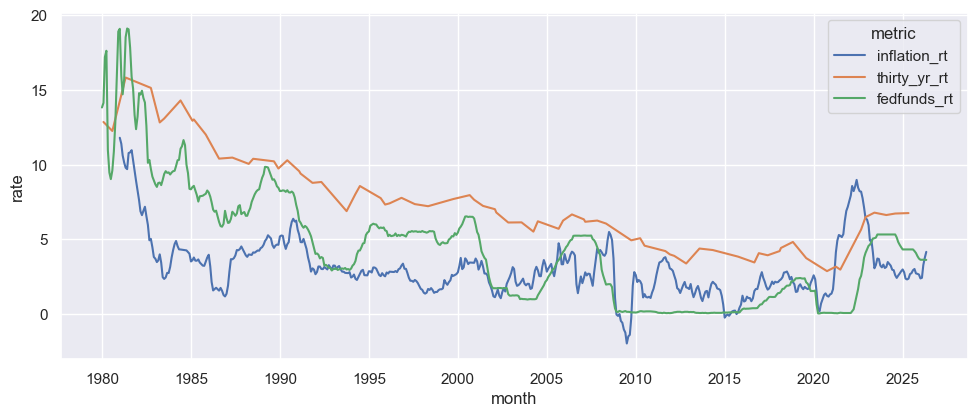

In [49]:
sns.set_theme(rc={'figure.figsize':(11.7,4.5)})

x = df_long.copy()
allowed_metrics = ['inflation_rt','fedfunds_rt','thirty_yr_rt']
x = x[x['metric'].isin(allowed_metrics)]
sns.lineplot(x, x='month', y='rate', hue='metric')

<Axes: xlabel='month', ylabel='rate'>

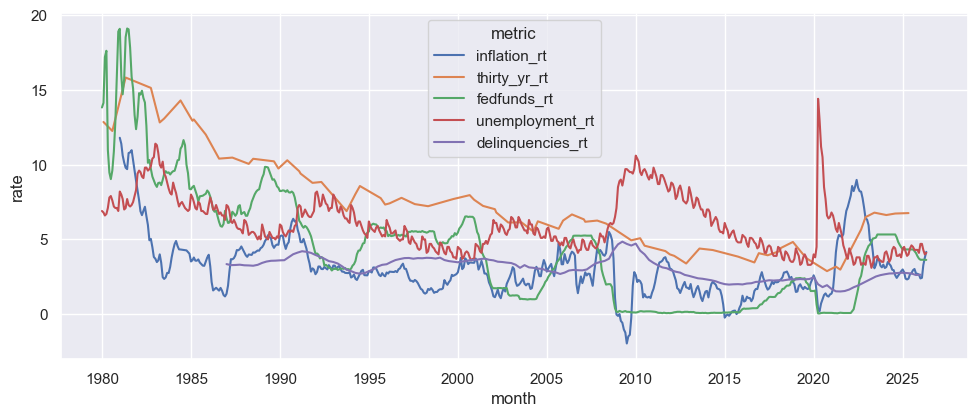

In [50]:
sns.set_theme(rc={'figure.figsize':(11.7,4.5)})

x = df_long.copy()
allowed_metrics = ['inflation_rt', 'thirty_yr_rt',
       'fedfunds_rt', 'unemployment_rt', 'delinquencies_rt']
x = x[x['metric'].isin(allowed_metrics)]
sns.lineplot(x, x='month', y='rate', hue='metric')

In [81]:
print('hello world')

hello world


In [ ]:
employed = pd.DataFrame(fred.get_series('PAYEMS')).reset_index() #mortgage rates
employed['employed_difference'] = employed[0] - employed[0].shift(1)
employed['employed_difference'] = employed['employed_difference']*1000
employed.columns = ['date','employed','employed_difference']

In [19]:
delinquencies

,delinquencies_rt
DATE,
2021-07-01,1.520
2021-10-01,1.550
2022-01-01,1.650
2022-04-01,1.800
2022-07-01,1.920
2022-10-01,2.070
2023-01-01,2.220
2023-04-01,2.370
2023-07-01,2.520


In [ ]:
fred.search('PAYEMS').head(5)

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
PAYEMS,PAYEMS,2026-06-13,2026-06-13,"All Employees, Total Nonfarm",1939-01-01,2026-05-01,Monthly,M,Thousands of Persons,Thous. of Persons,Seasonally Adjusted,SA,2026-06-05 08:31:36-05:00,86,"All Employees: Total Nonfarm, commonly known a..."
PAYNSA,PAYNSA,2026-06-13,2026-06-13,"All Employees, Total Nonfarm",1939-01-01,2026-05-01,Monthly,M,Thousands of Persons,Thous. of Persons,Not Seasonally Adjusted,NSA,2026-06-05 08:30:45-05:00,54,"All Employees: Total Nonfarm, commonly known a..."
